# Setup

In [1]:
import sys
sys.path.append("..")
import numpy as np
import torch
import gymnasium as gym
from gymnasium.wrappers import TimeLimit
from config import Config
from actor import Actor
from critic import Critic
from replay_buffer import ReplayBuffer
from tqdm import tqdm, trange
from utils import device

rng = np.random.default_rng(0)

env = gym.make("HalfCheetah-v5")
env = TimeLimit(env, max_episode_steps = 500)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

config = Config(
    state_dim = state_dim,
    action_dim = action_dim,
    action_tanh = False,
    num_encoders = 4,
    tree_depth = 3,
    num_hidden_layers = 3,
    embed_dim = 32,
    discount_rate = 0.95,
    learning_rate = 5e-3,
    polyak_factor = 0.05,
    batch_size = 64,
    num_episodes = 10000,
    replay_buffer_size = 1000,
    add_frequency = 0.2,
    update_interval = 10,
    noise_std = 0.02,
    noise_std_min = 0.0001,
    noise_std_decay = 0.99998,
)

actor = Actor(config, rng).to(device)
critic = Critic(config, rng).to(device)
replay = ReplayBuffer("replay.npy", config, rng = rng)
episode_rewards = []
noise_std = config.noise_std
reward_ema = 0.0

In [2]:
i = 0
for episode in trange(config.num_episodes):
    state, _ = env.reset(seed = episode)
    state = torch.tensor(state, dtype = torch.float32, device = device).unsqueeze(0)
    episode_reward = 0.0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        with torch.no_grad():
            actor_embeds, action = actor.forward(state, noise_std)
        next_state, reward, terminated, truncated, _ = env.step(action[0].cpu().numpy())
        next_state_t = torch.tensor(next_state, dtype = torch.float32, device = device).unsqueeze(0)
        reward_t = torch.tensor([[reward]], dtype = torch.float32, device = device)
        done_t = torch.tensor([[float(terminated or truncated)]], dtype = torch.float32, device = device)
        if np.random.rand() < config.add_frequency:
            replay.add(state, action, reward_t, done_t, next_state_t, actor_embeds)
        
        reward_ema = reward_ema * 0.99 + reward * 0.01

        i += 1
        if i % config.update_interval == 0:
            batch_state, batch_action, batch_reward, batch_done, batch_next_state, batch_embeds = replay.sample()
            critic_loss, target_q_value = critic.train(
                actor = actor,
                state = batch_state,
                actor_embeds = batch_embeds,
                action = batch_action,
                reward = batch_reward,
                done = batch_done,
                next_state = batch_next_state,
            )
            actor_loss = actor.train(critic = critic, state = batch_state)
        if i % 100 == 0:
            print(critic_loss, actor_loss, "|", target_q_value, reward_ema / (1 - 0.95), noise_std)

        noise_std = max(noise_std * config.noise_std_decay, config.noise_std_min)

        state = next_state_t
        episode_reward += float(reward)

    episode_rewards.append(episode_reward)

  0%|          | 0/10000 [00:00<?, ?it/s]

0.3710320293903351 0.5069698095321655 | -0.6482335329055786 -2.132306250322542 0.019960438782916146
0.1699594259262085 0.17426429688930511 | -0.6861450672149658 -2.720845651906382 0.019920557401210775
0.09897597134113312 0.5361970663070679 | -0.5087341666221619 -2.936127197783849 0.01988075570335523
0.2853902280330658 0.414334774017334 | -0.5439717769622803 -3.045805418061031 0.019841033530139506


  0%|          | 1/10000 [00:03<10:19:52,  3.72s/it]

0.06022966653108597 0.3313562572002411 | -0.6248634457588196 -3.152243943133331 0.019801390722671657
0.11989275366067886 0.3568514585494995 | -0.7153746485710144 -3.1497683803006757 0.01976182712237725
0.10563917458057404 0.21227502822875977 | -0.6775230169296265 -3.0756187192875863 0.019722342570998648
0.08856067061424255 0.22852823138237 | -0.6950398683547974 -3.1947546610632935 0.019682936910594452
0.11035913228988647 0.2701142132282257 | -0.7206974625587463 -3.186337494851523 0.01964360998353881


  0%|          | 2/10000 [00:07<9:42:38,  3.50s/it] 

...

3.6165592670440674 2.725353240966797 | -2.759218215942383 -3.130415227060313 0.007891158642969983
3.6728456020355225 0.06335856020450592 | -2.778693437576294 -3.132249635452517 0.007875391939975088
3.5784664154052734 -0.06029411405324936 | -2.7530078887939453 -3.1325493021408333 0.007859656739188505
3.5718038082122803 2.7308871746063232 | -2.749959945678711 -3.190380633054908 0.007843952977668137
3.560765027999878 -0.211880162358284 | -2.7482681274414062 -3.17933216994707 0.007828280592597651


  1%|          | 94/10000 [05:01<10:03:38,  3.66s/it]

3.584961175918579 2.7347869873046875 | -2.7538766860961914 -3.1639598071906594 0.007812639521286259
3.6581242084503174 -0.16913697123527527 | -2.7711808681488037 -3.1818391256060745 0.007797029701168394
3.571091651916504 -0.06380438804626465 | -2.752178192138672 -3.2158209324658564 0.0077814510698035
3.5916295051574707 1.2638537883758545 | -2.7566757202148438 -3.205774838367799 0.007765903564875788
3.694401741027832 2.7386999130249023 | -2.7553768157958984 -3.1785147031283323 0.0077503871241939816


  1%|          | 94/10000 [05:04<8:54:23,  3.24s/it] 


KeyboardInterrupt: 

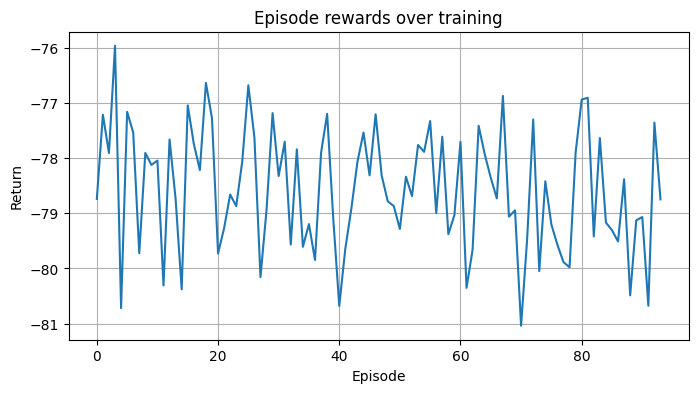

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 4))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Episode rewards over training")
plt.grid(True)
plt.show()

In [4]:
episode_rewards

[-88.21959116320716,
 -85.24133866155253,
 -86.94675136695854,
 -86.72988559477623,
 -89.82059683159525,
 -94.80580657514666,
 -97.20839737900366,
 -105.14213765542216]

In [11]:
from torch.nn.functional import mse_loss
from torch import optim
from torch.nn.utils import clip_grad_norm_
from utils import polyak_update


config = Config(
    state_dim = 8,
    action_dim = 1,
    action_tanh = False,
    num_encoders = 2,
    tree_depth = 2,
    num_hidden_layers = 2,
    embed_dim = 128,
    discount_rate = 0.95,
    polyak_factor = 0.05,
    batch_size = 64,
    num_episodes = 1,
    replay_buffer_size = 5000,
)

actor = Actor(config, rng)
optimizer = optim.Adam(actor.parameters(), lr = 1e-3)

for i in range(10000):
    state = torch.rand(config.batch_size, 8)
    next_state = torch.rand(config.batch_size, 8)
    _, next_q_value = actor.forward(next_state)
    target = 1 + 0.9 * next_q_value

    module_idx = rng.integers(0, len(actor._online_models))
    _, pred = actor.forward(state, module_idx)
    
    loss = mse_loss(pred, target)
    loss.backward()
    clip_grad_norm_(actor._online_models[module_idx].parameters(), max_norm = 1.0)
    optimizer.step()
    optimizer.zero_grad(set_to_none = True)
    polyak_update(actor._target_models[module_idx], actor._online_models[module_idx], config.polyak_factor)

    if i % 100 == 0:
        print(f"loss: {loss.item():.8f}, pred: {pred.mean().item():.8f}, target: {target.mean().item():.8f}")

loss: 0.99892157, pred: 0.00426890, target: 0.99789762
loss: 0.44309336, pred: 3.30071759, target: 3.96636915
loss: 0.34435290, pred: 4.13132191, target: 4.71813726
loss: 0.00010251, pred: 5.07801867, target: 5.08814287
loss: 0.21817899, pred: 5.32932377, target: 5.79642010
loss: 0.17227656, pred: 5.84938860, target: 6.26445055
loss: 0.00000905, pred: 6.64374733, target: 6.64675570
loss: 0.10951297, pred: 6.69045544, target: 7.02138233
loss: 0.08374909, pred: 7.10605574, target: 7.39545059
loss: 0.06809153, pred: 7.39039564, target: 7.65133953
loss: 0.05148801, pred: 7.73088312, target: 7.95779324
loss: 0.00000086, pred: 8.23291874, target: 8.23384476
loss: 0.03032572, pred: 8.25855541, target: 8.43269920
loss: 0.02362239, pred: 8.46284485, target: 8.61653996
loss: 0.01693525, pred: 8.69862843, target: 8.82876492
loss: 0.01175429, pred: 8.91557026, target: 9.02398682
loss: 0.00964625, pred: 9.01784134, target: 9.11605644
loss: 0.00727560, pred: 9.14688683, target: 9.23218441
loss: 0.00